<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico en Cáncer de Mama

**Notebook específico para el conjunto de datos TCGA-BRCA (`nsclc_ctdx_msk_2022_clinical_data.tsv`).**
**Targeted sequencing of ctDNA samples drawn from patients with metastatic NSCLC using the Resolution ctDx Lung platform.**
* Enlaze de descarga: (https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* Paper relacionado: Jee et al. Nature Medicine 2022.

Este cuaderno replica la lógica del notebook de METABRIC y la adapta a la cohorte TCGA:
1. carga y descripción del dataset clínico;
2. EDA reutilizando el módulo `EDA_functions.py`;
3. limpieza orientada a supervivencia;
4. preprocesamiento reproducible para Kaplan-Meier, Cox, Random Survival Forest y DeepSurv.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos. Las librerías específicas de modelado de supervivencia se importan de forma tolerante: si alguna no está instalada, el preprocesamiento puede ejecutarse igualmente y se mostrará un aviso.

In [1]:
# Sistema
import os
import sys
import warnings

# Ciencia de datos
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Supervivencia — scikit-survival
from sksurv.util import Surv

# Guardado de modelos
import joblib

# ── Configuración del entorno ────────────────────────────────────────────────
warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
importlib.reload(eda)

<module 'utils.EDA_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\EDA_functions.py'>

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), se extrajeron los datos directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los conjunstos de datos son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`. 
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data`.
* **TCGA-LUAD (Adenocarcinoma de pulmón) & TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [3]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/raw/brca_metabric_clinical_data.tsv",
    r"../data/raw/brca_tcga_gdc_clinical_data.tsv", 
    r"../data/raw/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

# 3. MSK-NSCLC — Metastatic Non-Small Cell Lung Cancer (MSK, 2022)

El estudio **MSK-NSCLC** es una cohorte clínica avanzada centrada en el cáncer de pulmón de células no pequeñas en estado metastásico. Su importancia radica en el uso de la plataforma de secuenciación dirigida **Resolution ctDx Lung**, diseñada específicamente para el análisis de ADN tumoral circulante (**ctDNA**) a partir de biopsias líquidas. Este enfoque permite capturar la heterogeneidad genómica del tumor de forma no invasiva.

A diferencia de los estudios basados exclusivamente en tejido sólido, este dataset integra métricas de carga tumoral sistémica, como el **Volumen Tumoral Metabólico (MTV)**, junto con perfiles mutacionales detectados en plasma. Es un recurso fundamental para la validación de biomarcadores de respuesta inmunológica y el desarrollo de modelos predictivos que combinan datos clínicos, genómicos (TMB, MSI) y volumétricos en pacientes con enfermedad avanzada.

Información complementaria:
* **Enlace de descarga:** [cBioPortal - MSK (Nature Medicine 2022)](https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* **Paper relacionado:** Jee et al. *Nature Medicine* 2022.
* **Dataset:** `nsclc_ctdx_msk_2022_clinical_data`
* **Conjuntos de datos completos con Variable, Descripción y Ejemplos:**

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| Study ID | Identificador único del estudio | nsclc_ctdx_msk_2022 |
| Patient ID | ID único del paciente | P-0047181 |
| Sample ID | ID de la muestra (ctDNA o tejido) | MSK-L-001-001A |
| Age at Which Sequencing was Reported | Edad del paciente al realizar la secuencia | 70, 72 |
| Patient Current Age | Edad actual o al último seguimiento | 60, 70, 80 |
| Age Greater than Median | Indicador de edad respecto a la mediana | True, False |
| Cancer Type | Categoría general de la neoplasia | Non-Small Cell Lung Cancer |
| Cancer Type Detailed | Clasificación histológica específica | Lung Adenocarcinoma |
| Ethnicity Category | Categoría étnica del paciente | Non-Hispanic |
| Extrapulmonary | Presencia de afectación fuera del pulmón | True, False |
| Fraction Genome Altered | Proporción del genoma con alteraciones | 0.1, 0.3 |
| Gene Panel | Panel de secuenciación utilizado | IMPACT468, ctDx Lung |
| Histology | Tipo celular del tumor | Adenocarcinoma, Squamous |
| Metabolic Tumor Volume | Volumen tumoral total por PET/CT | 100, 500.5 |
| Metastatic Site | Localización de la metástasis | Liver, Pleura, Bone |
| MSI Score | Puntuación de inestabilidad microsatelital | 0.05, 1.2 |
| MSI Type | Clasificación de estabilidad microsatelital | Stable |
| Mutation Count | Número total de mutaciones detectadas | 2, 5, 10 |
| Oncotree Code | Código en la taxonomía Oncotree | LUAD, LUSC |
| Overall Survival (Months) | Tiempo de supervivencia global en meses | 10.2, 30.5 |
| Overall Survival Status | Estado vital del paciente (evento) | 0:LIVING, 1:DECEASED |
| Patient Display Name | Nombre o código público del paciente | MSK-L-983 |
| Primary Tumor Site | Sitio de origen del tumor primario | Lung |
| Prior Treatment | Recibió tratamiento antes de la muestra | True, False |
| Race Category | Clasificación racial del paciente | WHITE, ASIAN, BLACK |
| Sample Class | Clase de material biológico | cfDNA, Tumor |
| Number of Samples Per Patient | Total de muestras analizadas por individuo | 1, 2, 4 |
| Sample Type | Naturaleza de la muestra | Metastasis |
| Sex | Sexo biológico del paciente | Male, Female |
| Site | Centro médico donde se trató | MSK |
| Smoking Status | Antecedentes de tabaquismo | True, False |
| Stage at Draw | Estadio clínico al momento de la toma | 4 |
| Successful ctDx Lung | Éxito técnico del análisis ctDx | True, False |
| TMB (nonsynonymous) | Carga mutacional (mut/Mb) | 3.1, 6.5, 12.0 |
| Tumor Purity | Porcentaje estimado de células tumorales | 10, 20, 30 |

Puntos críticos para supervivencia:

* `Overall Survival (Months)` actúa como la variable de tiempo hasta el evento.
* `Overall Survival Status` define si ocurrió el fallecimiento (`1:DECEASED`) o si el dato está censurado (`0:LIVING`).
* El **Metabolic Tumor Volume (MTV)** es una covariable crítica en este dataset, ya que a menudo correlaciona con la cantidad de ctDNA detectado y el pronóstico.
* Se debe prestar atención a `Prior Treatment`, ya que los pacientes previamente tratados pueden presentar perfiles mutacionales de resistencia que alteran significativamente las curvas de supervivencia en comparación con pacientes *naive*.

## **3.1. Descripción del conjunto de datos (MSK-NSCLC)**

### **A. Dimensiones y tipo de datos**

El conjunto de datos **MSK-NSCLC** presenta una estructura robusta caracterizada por un alto volumen de muestras longitudinales y multimodales, superando significativamente en registros a cohortes como TCGA-BRCA:

*   **Dimensiones globales:** El dataset está compuesto por **2.621 registros (muestras)** y **35 variables (columnas)**.
*   **Granularidad y Multi-muestreo:** Se identifican **1.127 pacientes únicos**, lo que implica una alta tasa de duplicidad de identificadores de paciente (**1.494 filas duplicadas**). Esta redundancia es intencionada, ya que refleja el seguimiento de pacientes con múltiples tomas de muestras en diferentes momentos o sitios (ej. tumor primario vs. metástasis) y diferentes naturalezas biológicas (`Sample Class`: cfDNA frente a tejido tumoral).
*   **Tipología de datos:**
    *   **Variables numéricas (`float64`, `int64`):** Comprenden métricas de supervivencia, carga mutacional y parámetros de volumen tumoral (ej. `Overall Survival (Months)`, `TMB`, `Mutation Count`, `Metabolic Tumor Volume`).
    *   **Variables categóricas y booleanas (`str`, `object`, `bool`):** Incluyen clasificaciones histológicas, antecedentes clínicos y éxito técnico de la plataforma (ej. `Cancer Type Detailed`, `Smoking Status`, `Prior Treatment`, `Successful ctDx Lung`).

### **B. Valores nulos**

La cohorte de MSK presenta una integridad excepcional en los *endpoints* primarios, aunque muestra una dispersión considerable en métricas genómicas y volumétricas específicas:

*   **Integridad Absoluta (0% nulos):** Las variables críticas para el análisis de supervivencia, como `Overall Survival (Months)` y `Overall Survival Status`, presentan un **0% de ausencia**, lo que garantiza la solidez de los modelos de tiempo hasta el evento. Igualmente, los identificadores y el tipo de cáncer están totalmente informados.
*   **Alta Fiabilidad Clínica (0.38% - 5.15% nulos):** Variables demográficas y clínicas esenciales como `Sex`, `Histology`, `Smoking Status`, `Prior Treatment` y el estadio al momento de la toma (`Stage at Draw`) muestran una completitud casi total, facilitando su uso como covariables.
*   **Bloque de Información Genómica y Demográfica (~15% - 53% nulos):**
    *   **Demografía:** La raza y la edad actual presentan un **14.8%** de nulos.
    *   **Genómica:** Existe una fragmentación notable en biomarcadores avanzados. Mientras que `Mutation Count` falta en el **25.2%** de los casos, la carga mutacional (`TMB`) y el origen del tumor primario superan el **52%** de ausencia, reflejando la dificultad de obtener perfiles completos en contextos metastásicos.
*   **Fragmentación por Especialización (>60% nulos):**
    *   Las variables relacionadas con biopsia líquida y parámetros de imagen avanzada presentan la mayor carencia: `Tumor Purity` (**61.2%**), `Age at Sequencing` (**64%**) y `Metabolic Tumor Volume` (**85.7%**). Estos datos no indican un error, sino que son medidas específicas realizadas solo en subgrupos seleccionados de la cohorte original.

> **Decisión de granularidad:** Para el desarrollo de modelos de supervivencia, el dataset se reducirá a una entrada por paciente. Se priorizará la muestra categorizada como `Tumor` (tejido sólido) sobre `cfDNA` para mantener la consistencia con otros datasets, o en su defecto, la muestra con el perfil genómico más completo, asegurando que cada registro represente la carga biológica del paciente al inicio del estudio.

In [4]:
# Acceder al DataFrame por su clave:
nsclc = diccionario_datos['nsclc_ctdx_msk_2022_clinical_data']
eda.describe_df(nsclc)

Dimensiones del DataFrame: 2621 filas, 35 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,2621,0.00,1,nsclc_ctdx_msk_2022 (2621),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,2621,0.00,1127,"P-0047181 (22), P-0024335 (17), P-0014232 (14)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,2621,0.00,2621,"MSK-L-001-001A (1), MSK-L-002-001B (1), MSK-L-002-002 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Which Sequencing was Reported (Years),str,942,64.06,61,"71 (43), 72 (41), 70 (38)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patient Current Age,float64,2233,14.80,58,None,66.787282,68.000000,11.554103,31.000000,59.000000,74.000000,90.000000
5,Age Greater than Median,object,2591,1.14,2,"False (2142), True (449)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,str,2621,0.00,19,"Non-Small Cell Lung Cancer (2539), Cancer of Unknown Primary (48), Small Cell Lung Cancer (8)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,str,2621,0.00,36,"Lung Adenocarcinoma (2191), Non-Small Cell Lung Cancer (190), Lung Squamous Cell Carcinoma (124)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ethnicity Category,str,2218,15.38,6,"Non-Spanish; Non-Hispanic (2083), Spanish NOS; Hispanic NOS, Latino NOS (59), Unknown whether Spanish or not (56)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Extrapulmonary,object,1040,60.32,2,"True (766), False (274)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Resumen de valores nulos
eda.null_summary(nsclc)

,Column,Data Type,Non-null Count,Null Count,% Null Values,TotalCount
0,Metabolic Tumor Volume,float64,374,2247,85.73,2621
1,Metastatic Site,str,542,2079,79.32,2621
2,MSI Type,str,920,1701,64.90,2621
3,Age at Which Sequencing was Reported (Years),str,942,1679,64.06,2621
4,Fraction Genome Altered,float64,953,1668,63.64,2621
5,Tumor Purity,str,1016,1605,61.24,2621
6,Extrapulmonary,object,1040,1581,60.32,2621
7,MSI Score,float64,1231,1390,53.03,2621
8,Primary Tumor Site,str,1255,1366,52.12,2621
9,TMB (nonsynonymous),float64,1257,1364,52.04,2621


In [6]:
# Duplicados por paciente y granularidad muestra-paciente
n_patients = nsclc["Patient ID"].nunique()
n_samples = nsclc["Sample ID"].nunique()
n_duplicated_patients = nsclc["Patient ID"].duplicated().sum()

print(f"Pacientes únicos : {n_patients}")
print(f"Muestras únicas  : {n_samples}")
print(f"Filas con Patient ID duplicado: {n_duplicated_patients}")

nsclc.loc[
    nsclc["Patient ID"].duplicated(keep=False),
    ["Patient ID", "Sample ID", "Sample Type", "Overall Survival (Months)", "Overall Survival Status"]
].sort_values(["Patient ID", "Sample ID"]).head(20)

Pacientes únicos : 1127
Muestras únicas  : 2621
Filas con Patient ID duplicado: 1494


,Patient ID,Sample ID,Sample Type,Overall Survival (Months),Overall Survival Status
9,MSK-L-003,MSK-L-003-001A,Metastasis,55.551905,0:LIVING
10,MSK-L-003,MSK-L-003-003,Metastasis,55.551905,0:LIVING
169,MSK-L-1034,MSK-L-1034-001,Metastasis,15.768725,1:DECEASED
170,MSK-L-1034,MSK-L-1034-004,Metastasis,15.768725,1:DECEASED
300,MSK-L-1158,MSK-L-1158-001,Metastasis,23.390276,1:DECEASED
301,MSK-L-1158,MSK-L-1158-003,Metastasis,23.390276,1:DECEASED
302,MSK-L-1158,MSK-L-1158-005,Metastasis,23.390276,1:DECEASED
895,MSK-L-703,MSK-L-703-001,Metastasis,36.103811,0:LIVING
896,MSK-L-703,MSK-L-703-002,Metastasis,36.103811,0:LIVING
443,P-0000604,MSK-L-228-001,Metastasis,60.282523,1:DECEASED


**Decisión de granularidad:** para los modelos de supervivencia se utilizará una única fila por paciente. En esta cohorte hay múltiples muestras por paciente, pero el endpoint de supervivencia es paciente-específico. Más adelante se deduplicará tras filtrar a NSCLC y se priorizarán muestras con mayor cobertura genómica.

## **3.2. Análisis estadístico básico**

En este apartado se realiza un análisis estadístico básico del conjunto de datos `nsclc_ctdx_msk_2022_clinical_data`. El objetivo es explorar las principales características de las variables disponibles, distinguiendo entre variables categóricas y variables numéricas, y agrupándolas según sus familias lógicas (identificadores, metadatos, clinico-demográficos, anatómicas, entre otras).

### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables categóricas organizadas por familias lógicas:

#### **A. Identificadores y Metadatos del Estudio**

* **`Study ID` (Constante):** Todos los casos pertenecen al estudio **nsclc_ctdx_msk_2022**, por lo que esta variable no aporta variabilidad biológica ni clínica, pero sí sirve para trazabilidad.

* **`Patient ID`, `Sample ID` y `Patient Display Name` (Alta Cardinalidad):** Hay **1127 pacientes** y **2621 muestras**, lo que confirma que varios pacientes aportan múltiples muestras. Estas variables no deben utilizarse como predictores en modelos, ya que pueden introducir fuga de información o sobreajuste.

* **`Site` (Predominio MSK):** La gran mayoría de muestras proceden de **MSK** (**2476**) y una proporción menor de **Sydney** (**125**). Esta variable puede capturar diferencias institucionales o técnicas, aunque su fuerte desbalance limita comparaciones directas.

* **Lectura global:** Este bloque describe estructura, procedencia y trazabilidad. Es fundamental para control de calidad y particionado correcto de datos, especialmente porque hay múltiples muestras por paciente. 


In [7]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        'Study ID', 'Patient ID', 'Sample ID', 'Patient Display Name', 'Site'
    ])],
    group_name="Identificadores y Metadatos del Estudio",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Identificadores_y_Metadatos_del_Estudio.html


#### **B. Perfil Demográfico y Riesgo**

* **`Sex` (Distribución Mixta):** La cohorte incluye **1539 mujeres** y **1072 hombres**. Aunque hay predominio femenino, ambos sexos están ampliamente representados, lo que permite comparaciones más robustas que en cohortes muy desbalanceadas.

* **`Race Category` (Predominio White):** Predomina la categoría **WHITE** con **1640 casos**, seguida por **ASIAN-FAR EAST/INDIAN SUBCONTINENT** con **358** y **BLACK OR AFRICAN AMERICAN** con **115**. Esto muestra diversidad parcial, pero con clara sobrerrepresentación de pacientes blancos.

* **`Ethnicity Category` (Predominio no hispano):** La mayoría de pacientes aparece como **Non-Spanish / Non-Hispanic**, con **2083 casos**. Los grupos hispanos o de etnicidad desconocida son minoritarios, por lo que los análisis por etnicidad tendrán menor potencia.

* **`Smoking Status` (Casi Balanceado):** Hay **1397 fumadores** frente a **1194 no fumadores**. Esta variable es especialmente relevante en NSCLC, ya que el tabaquismo se asocia con mayor carga mutacional, perfiles genómicos distintos y posible impacto en TMB.

* **`Age Greater than 65` (Categoría Clínica):** Hay **2142 pacientes ≤65 o no marcados como mayores de 65** frente a **449 mayores de 65** según la codificación categórica. Esta variable puede simplificar análisis de edad, aunque pierde granularidad respecto a `Patient Current Age`.

* **Lectura global:** La cohorte representa una población clínica amplia de NSCLC, con edad avanzada, distribución por sexo relativamente equilibrada, predominio de pacientes blancos y una proporción alta de fumadores. 

In [8]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        'Sex', 'Race Category', 'Ethnicity Category', 'Smoking Status', 'Age at Which Sequencing was Reported (Years)', 'Age Greater than Median'
    ])],
    group_name="Perfil Clínico-Demográfico y Anatómico",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Perfil_Clínico-Demográfico_y_Anatómico.html


#### **C. Clasificacion Patológica y Diagnostica**

* **`Cancer Type` (Dominio NSCLC):** La categoría dominante es **Non-Small Cell Lung Cancer**, con **2539 casos**. El resto de diagnósticos aparecen como categorías residuales o poco frecuentes, lo que confirma que la cohorte está fuertemente centrada en NSCLC.

* **`Cancer Type Detailed` (Dominio Adenocarcinoma):** Predomina **Lung Adenocarcinoma** con **2191 casos**, seguido por **Non-Small Cell Lung Cancer NOS** con **190** y **Lung Squamous Cell Carcinoma** con **124**. Esto indica una cohorte mayoritariamente adenocarcinoma pulmonar, con menor representación de carcinoma escamoso.

* **`Histology` (Adenocarcinoma como Fenotipo Modal):** La categoría **Adenocarcinoma** domina con **2268 casos**, seguida por **Other** y **Squamous Cell Carcinoma**. Este patrón es clínicamente importante porque el adenocarcinoma se asocia con mayor frecuencia de alteraciones accionables como EGFR, ALK, ROS1, MET o RET.

* **`Oncotree Code` (Confirmación Molecular/Diagnóstica):** El código **LUAD** domina con **2191 casos**, seguido por **NSCLC** y **LUSC**. Esto reproduce la estructura histológica: adenocarcinoma pulmonar como entidad central, carcinoma escamoso como subgrupo menor y categorías NOS como diagnóstico menos específico.

* **Lectura global:** La cohorte MSK_NSCLC está compuesta principalmente por adenocarcinoma pulmonar avanzado. Por tanto, los resultados moleculares y pronósticos estarán muy influenciados por la biología de LUAD más que por NSCLC en sentido amplio. 

In [9]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Histology'
    ])],
    group_name="Clasificacion Patológica y Diagnostica",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Clasificacion_Patológica_y_Diagnostica.html


#### **D. Localización y Naturaleza de la Muestra**

* **`Sample Class` (Predominio cfDNA):** Hay **1667 muestras cfDNA** frente a **954 muestras tumorales**. Esto indica que gran parte de la cohorte procede de biopsia líquida, lo que tiene implicaciones técnicas: menor dependencia de tejido disponible, pero posible variabilidad por fracción tumoral circulante.

* **`Sample Type` (Predominio Metástasis):** La mayoría de muestras son **Metastasis** (**1964**), frente a **Primary** (**490**), **Unknown** (**164**) y pocos casos de recurrencia local. Esto confirma que la cohorte captura principalmente enfermedad avanzada/metastásica.

* **`Metastatic Site` (Heterogeneidad Anatómica):** Los sitios metastásicos más frecuentes son **ganglio linfático**, **pleura**, **hígado**, **hueso** y **cerebro**. La distribución es amplia, con más de 50 sitios codificados, lo que refleja una cohorte con enfermedad diseminada y anatómicamente heterogénea.

* **`Primary Tumor Site` (Pulmón Dominante):** El sitio primario más común es **Lung** con **1170 casos**, aunque existen categorías como desconocido o tumores extrapulmonares minoritarios. Esto puede reflejar casos con clasificación compleja o muestras incorporadas por contexto diagnóstico.

* **`Extrapulmonary` (Frecuencia Alta):** La categoría **True** aparece en **766 casos**, frente a **274 False**. Esto es coherente con una cohorte con alta proporción de muestras metastásicas o procedentes de localizaciones fuera del pulmón primario.

* **Lectura global:** Este bloque refuerza que MSK_NSCLC no es una cohorte de tumores primarios tempranos, sino una cohorte avanzada, muy enriquecida en metástasis y biopsias líquidas. 

In [37]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin(['Sample Calss', 'Sample Type', 'Metastatic Site', 'Primary Tumor Site', 'Extrapulmonary'
    ])],
    group_name="Localización y Naturaleza de la Muestra",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
    ,ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Localización_y_Naturaleza_de_la_Muestra.html


#### **E. Metodología y Calidad Genómica**

* **`Gene Panel` (Heterogeneidad Técnica):** El panel más frecuente es **ctDx_lung_panel** con **1364 casos**, seguido por **IMPACT468** con **848** y **ACCESS129** con **303**. Esta heterogeneidad metodológica es relevante porque distintos paneles pueden cubrir distintos genes y regiones, afectando el número de mutaciones detectadas y la comparabilidad de TMB.

* **`MSI Type` (Predominio Stable):** La categoría **Stable** domina con **817 casos**, mientras que **Instable** aparece solo en **4 casos**. Esto confirma que la inestabilidad microsatelital alta es muy rara en esta cohorte de NSCLC.

* **`Tumor Purity` (Concentración en Purezas Bajas-Moderadas):** Los valores más frecuentes están entre **10 y 40%**, con picos en **30**, **20** y **10**. Esto sugiere que muchas muestras tienen pureza tumoral limitada o moderada, lo que puede afectar sensibilidad para detectar variantes, especialmente en muestras de tejido heterogéneo o cfDNA.

* **Lectura técnica global:** La cohorte combina diferentes plataformas genómicas y calidades de muestra. Esto debe considerarse en cualquier análisis molecular, especialmente al comparar `Mutation Count`, `TMB`, MSI o alteraciones genómicas entre pacientes. 

In [38]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "Gene Panel", "MSI Type", "Successful ctDx Lung", "Tumor Purity"
    ])],
    group_name="Metodología y Calidad Genómica",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Metodología_y_Calidad_Genómica.html


#### **F. Variable Objetivo y Tratamiento**

* **`Overall Survival Status` (Distribución Balanceada):** La variable objetivo está casi equilibrada: **1322 fallecidos** frente a **1299 vivos**. A diferencia de muchas cohortes oncológicas desbalanceadas, aquí el evento de muerte tiene una frecuencia muy alta, lo que sugiere una cohorte clínicamente avanzada y útil para análisis pronósticos.

* **`Prior Treatment` (Alta Frecuencia):** Hay **1561 casos sin tratamiento previo** registrado y **1030 con tratamiento previo**. La proporción tratada es considerable, por lo que el historial terapéutico puede actuar como factor de confusión importante. Los pacientes tratados previamente pueden representar enfermedad más evolucionada, resistencia terapéutica o líneas posteriores de manejo.

* **Lectura clínica global:** La cohorte tiene una variable de supervivencia fuerte y relativamente balanceada, junto con heterogeneidad terapéutica relevante. Esto la hace adecuada para modelos pronósticos, pero exige controlar por tratamiento previo para evitar sesgos. 


In [12]:
eda.plot_categorical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "Overall Survival Status", "Prior Treatment"
    ])],
    group_name="Variable Objetivo y Tratamiento",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Categorical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_cat_Variable_Objetivo_y_Tratamiento.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables numéricas organizadas por familias lógicas:

#### **A. Métricas de Supervivencia**

* **`Patient Current Age` (Distribución Unimodal, Edad Avanzada):** La edad actual se concentra principalmente entre los **59 y 74 años**, con mediana cercana a **68 años**. El pico visual se sitúa alrededor de los **70–72 años**, lo que indica una cohorte dominada por pacientes de edad avanzada, consistente con el perfil epidemiológico del cáncer de pulmón no microcítico. Los valores van desde **31 hasta 90 años**, por lo que existen casos jóvenes, pero son minoritarios.

* **`Overall Survival (Months)` (Sesgo Positivo):** La supervivencia global presenta una distribución fuertemente asimétrica hacia la derecha. La mediana está alrededor de **19.7 meses**, pero existen casos con supervivencias prolongadas de hasta **181 meses**. El grueso de los pacientes se acumula en los primeros meses de seguimiento, lo que sugiere una cohorte clínicamente agresiva, con una cola de largos supervivientes.

* **Lectura clínica conjunta:** La cohorte combina pacientes de edad avanzada con supervivencias muy heterogéneas. La presencia de una cola larga en supervivencia indica que, aunque muchos pacientes tienen evolución corta o seguimiento limitado, existe un subconjunto con control prolongado de la enfermedad. 


In [13]:
eda.plot_numerical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "Overall Survival (Months)",
        "Patient Current Age"
    ])],
    group_name="Métricas de Supervivencia y Tiempo",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Métricas_de_Supervivencia_y_Tiempo.html


#### **B. Carga Genómica y Estabilidad Molecular**

* **`Fraction Genome Altered` (Sesgo Positivo):** La fracción del genoma alterado tiene mediana aproximada de **0.12**, con la mayoría de casos concentrados en valores bajos. Sin embargo, existen casos que llegan hasta **0.94**, lo que indica tumores con inestabilidad cromosómica muy marcada. La distribución sugiere una cohorte donde predominan tumores con alteración genómica baja-moderada, pero con un subgrupo altamente alterado.

* **`MSI Score` (Concentración Baja con Outliers):** La mayoría de valores se agrupa cerca de valores bajos o incluso codificaciones negativas, con mediana cercana a **0.05**. Hay una cola extrema que alcanza **34.35**, compatible con pocos casos con señales fuertes de inestabilidad microsatelital. Visualmente, esto apunta a que la gran mayoría de NSCLC en esta cohorte no presenta un fenotipo MSI-alto.

* **`Mutation Count` (Sesgo Positivo Moderado):** El recuento de mutaciones se concentra en valores bajos: mediana de **3 mutaciones**, con el grueso entre **1 y 6**. Sin embargo, hay casos que alcanzan hasta **96 mutaciones**, representando tumores más hipermutados o con mayor exposición mutagénica.

* **`TMB (nonsynonymous)` (Sesgo Positivo):** La TMB tiene mediana cercana a **5.19**, con valores máximos de **83.01**. La mayoría de tumores tiene TMB baja-intermedia, pero existe una cola de casos con carga mutacional elevada. Dado que TMB y `Mutation Count` correlacionan **0.92**, ambas variables describen el mismo eje principal de carga mutacional tumoral.

* **Lectura molecular global:** MSK_NSCLC muestra una cohorte dominada por tumores molecularmente estables o de carga mutacional moderada, con un subconjunto pequeño de tumores altamente mutados o genómicamente alterados. Estos outliers pueden ser especialmente relevantes para estudiar respuesta inmunológica o sensibilidad a terapias dirigidas. 

In [14]:
eda.plot_numerical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "TMB (nonsynonymous)",
        "Mutation Count",
        "Fraction Genome Altered",
        "MSI Score"
    ])],
    group_name="Carga Genómica y Estabilidad Molecular",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Carga_Genómica_y_Estabilidad_Molecular.html


#### **C. Carga Tumoral Física y Estadificación**

* **`Metabolic Tumor Volume` (Sesgo Positivo Extremo):** La distribución está muy desplazada hacia valores bajos e intermedios, con mediana aproximada de **193**, pero con una cola larga que llega hasta **5390**. Esto indica que la mayoría de pacientes tiene una carga tumoral metabólica moderada, mientras que un subconjunto presenta enfermedad volumétricamente muy extensa.

* **`Stage at Draw` (Variable Constante):** Todos los casos codificados se concentran en el valor **4**. Esto indica que la cohorte representa esencialmente enfermedad avanzada al momento de la extracción de la muestra. Como no hay variabilidad, esta variable no aporta capacidad discriminativa dentro de la cohorte, pero sí define el contexto clínico: pacientes mayoritariamente en estadio IV.

* **Lectura clínica conjunta:** La cohorte parece centrada en NSCLC avanzado/metastásico. La variabilidad pronóstica no vendría dada por el estadio, que es constante, sino por factores como carga tumoral metabólica, perfil molecular, tratamiento previo, estado vital y localización de la muestra. 

In [15]:
eda.plot_numerical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "Metabolic Tumor Volume",
        "Stage at Draw"
    ])],
    group_name="Carga Tumoral Física y Estadificación",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Carga_Tumoral_Física_y_Estadificación.html


#### **D. Granularidad del Seguimiento**

* **`Number of Samples Per Patient` (Sesgo Positivo):** La mayoría de pacientes tiene pocas muestras, con mediana de **3 muestras por paciente**, pero existen casos con hasta **22 muestras**. Esto indica una cohorte con seguimiento longitudinal desigual: algunos pacientes aportan una única o pocas muestras, mientras que otros tienen múltiples mediciones a lo largo de su evolución clínica.

* **Interpretación analítica:** Esta variable no representa agresividad biológica directa. Más bien refleja intensidad de seguimiento, recurrencia de biopsias, monitorización molecular o disponibilidad de cfDNA. Su correlación positiva con supervivencia puede deberse a que los pacientes que viven más tiempo tienen más oportunidades de ser muestreados repetidamente. 

In [16]:
eda.plot_numerical_subplots(
    df=nsclc.loc[:, nsclc.columns.isin([
        "Number of Samples Per Patient"
    ])],
    group_name="Granularidad del Seguimiento",
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC",
    ncol=1
)

✔ Numerical subplots guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_num_subplots_Granularidad_del_Seguimiento.html


### **3.2.3. Análisis de Correlaciones**

Basado en el resumen de Pearson y el mapa de calor proporcionado para la cohorte **MSK_NSCLC**, presento la interpretación técnica siguiendo el formato de tu ejemplo previo:

* **`Mutation Count` vs `TMB (nonsynonymous)` (Correlación Muy Alta, r = 0.92):** Es la relación dominante del mapa de calor. Tiene sentido biológico y técnico: a mayor número absoluto de mutaciones, mayor carga mutacional tumoral no sinónima. Esta correlación indica que ambas variables capturan prácticamente el mismo eje molecular de carga mutacional, por lo que en modelos predictivos podrían ser redundantes.

* **`MSI Score` vs `Mutation Count` (Correlación Moderada, r = 0.32):** La asociación positiva sugiere que tumores con mayor inestabilidad microsatelital tienden a acumular más mutaciones. Sin embargo, la relación no es fuerte, lo que indica que la mayoría de la variabilidad mutacional no se explica únicamente por MSI.

* **`MSI Score` vs `Fraction Genome Altered` (r = 0.27) y `MSI Score` vs `TMB` (r = 0.22):** Estas correlaciones positivas pero moderadas-bajas sugieren una conexión parcial entre inestabilidad molecular y carga genómica, aunque no representan un mismo fenómeno. MSI, alteración cromosómica y TMB parecen capturar dimensiones relacionadas pero no equivalentes de agresividad molecular.

* **`Metabolic Tumor Volume` vs `Overall Survival (Months)` (Correlación Negativa, r = -0.19):** Es una de las relaciones clínicas más interpretables. A mayor volumen tumoral metabólico, tiende a observarse menor supervivencia global. Aunque la correlación es débil, su dirección es clínicamente coherente: una mayor carga tumoral física puede asociarse con peor pronóstico.

* **`Number of Samples Per Patient` vs `Overall Survival` (r = 0.24):** Esta correlación positiva probablemente refleja un sesgo de seguimiento: los pacientes con más tiempo de evolución o más intervenciones clínicas tienen más oportunidades de generar múltiples muestras. No debe interpretarse directamente como que tener más muestras mejora la supervivencia.

* **Lectura global del mapa:** Salvo la relación `Mutation Count`–`TMB`, el resto de correlaciones son bajas. Esto indica que la edad, la carga tumoral física, la supervivencia, la inestabilidad molecular y la granularidad muestral capturan dimensiones relativamente independientes de la cohorte.

> **Se convierten a numericas para evaluar su correlacion con otras variables:**

In [17]:
# Quitamos % y convertimos a número (errors='coerce' transforma 'default' en NaN automáticamente)
nsclc['Tumor Purity_numeric'] = pd.to_numeric(nsclc['Tumor Purity'].astype(str).str.replace('%', ''), errors='coerce')

nsclc['Age at Which Sequencing was Reported (Years)_numeric'] = pd.to_numeric(nsclc['Age at Which Sequencing was Reported (Years)'].replace('>90', 90))

✔ Heatmap guardado en: ..\images\EDA\MSK_NSCLC\MSK_NSCLC_heatmap_correlaciones.png


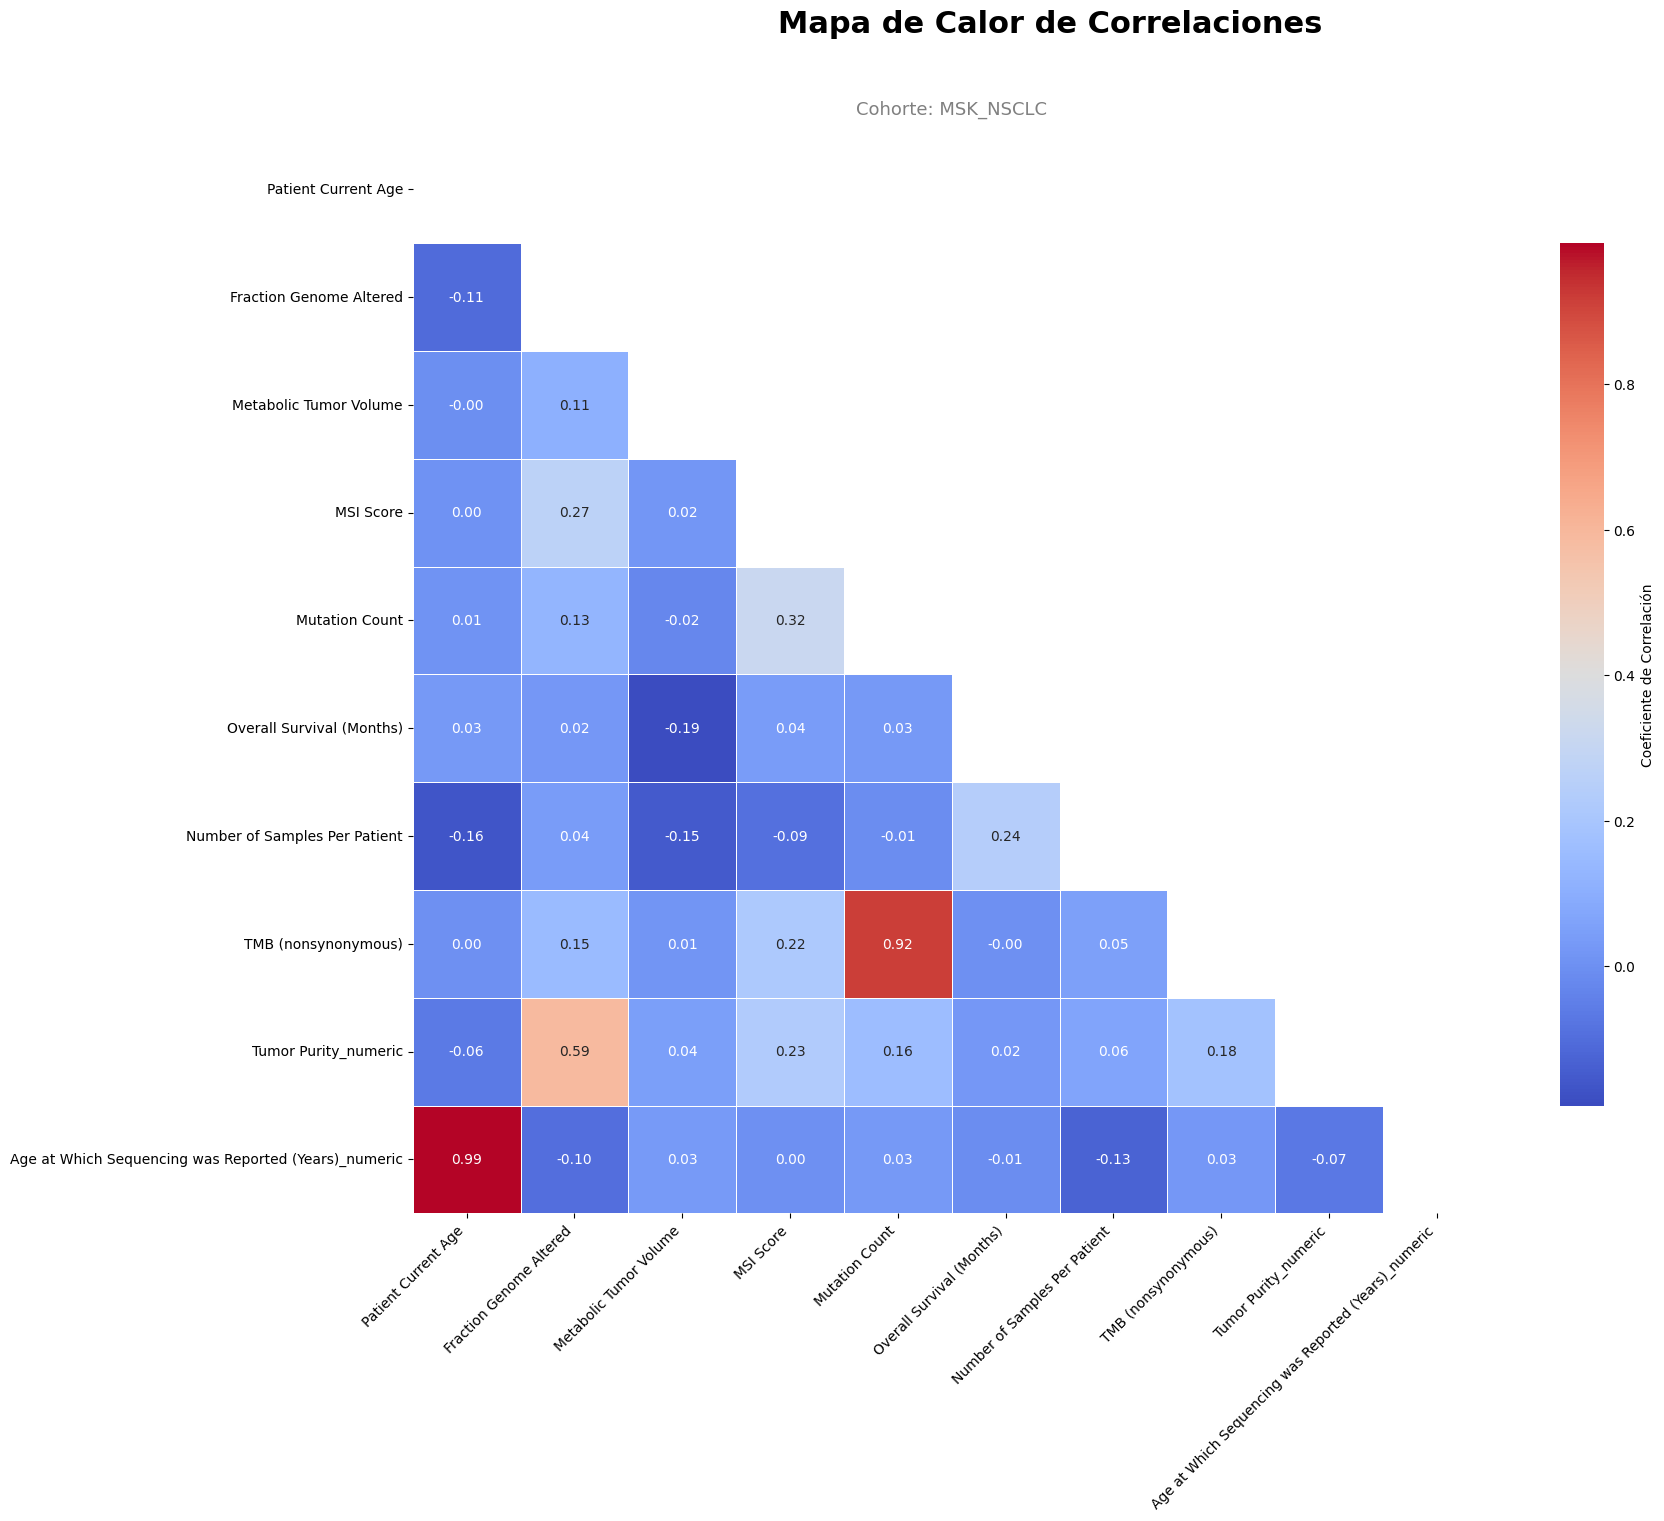


════════════════════════════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — MSK_NSCLC (Pearson)
════════════════════════════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                                          Corr
  ────────── ────────────────────────────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    Age at Which Sequencing was Reported (Years)_numeric  ↔  Patient Current Age            0.9935
  ▲ Top 2    TMB (nonsynonymous)  ↔  Mutation Count                                                  0.9175
  ▲ Top 3    Tumor Purity_numeric  ↔  Fraction Genome Altered                                        0.5893
  ▲ Top 4    Mutation Count  ↔  MSI Score                                                            0.3164
  ▲ Top 5    MSI Score  ↔  Fraction Genome Altered                                          

In [18]:
eda.plot_correlation_heatmap(
    df=nsclc.drop(columns=['Stage at Draw']),
    dataset_name="MSK_NSCLC",
    output_path=r"..\images\EDA\MSK_NSCLC"
)

## **3.3. Preprocesado de los datos**

Una vez analizados los atributos descriptivos, se prepararon para que nos sean útiles de cara a predecir valores.

In [19]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
nsclc_prep = nsclc.copy()

print(f"Shape inicial: {nsclc_prep.shape}")

Shape inicial: (2621, 37)


### **3.3.1. Filtrado explícito a NSCLC**

El archivo contiene algunas filas con otros diagnósticos, normalmente por muestras múltiples o anotaciones alternativas. Para este notebook se mantiene la cohorte principal de **Non-Small Cell Lung Cancer**.

In [20]:
# Filtrar y reportar en 3 líneas
n_pre = len(nsclc_prep)
nsclc_prep = nsclc_prep[nsclc_prep["Cancer Type"] == "Non-Small Cell Lung Cancer"].copy()

print(f"Eliminados: {n_pre - len(nsclc_prep)} | Registros actuales: {nsclc_prep.shape}")
nsclc_prep["Cancer Type"].value_counts().to_frame()

Eliminados: 82 | Registros actuales: (2539, 37)


,count
Cancer Type,
Non-Small Cell Lung Cancer,2539


### **3.3.2. Selección de una muestra por paciente**

El endpoint de supervivencia es paciente-específico. Para evitar duplicados, se selecciona una fila por `Patient ID`.

Criterio por defecto:

1. priorizar `Tumor` frente a `cfDNA`, porque maximiza la completitud de métricas genómicas agregadas como FGA/TMB/MSI;
2. priorizar `Primary` frente a `Metastasis`, si existe;
3. elegir de forma determinista por `Sample ID`.

Si el análisis se quisiera restringir estrictamente a biopsia líquida, basta con invertir `SAMPLE_CLASS_PRIORITY`.

In [21]:
n_antes = len(nsclc_prep)

SAMPLE_CLASS_PRIORITY = {
    "Tumor": 0,
    "cfDNA": 1,
}

SAMPLE_TYPE_PRIORITY = {
    "Primary": 0,
    "Metastasis": 1,
    "Local Recurrence": 2,
    "Unknown": 3,
}

if "Patient ID" in nsclc_prep.columns:
    nsclc_prep["__sample_class_priority"] = (
        nsclc_prep.get("Sample Class", pd.Series(index=nsclc_prep.index, dtype=object))
        .map(SAMPLE_CLASS_PRIORITY)
        .fillna(9)
    )
    nsclc_prep["__sample_type_priority"] = (
        nsclc_prep.get("Sample Type", pd.Series(index=nsclc_prep.index, dtype=object))
        .map(SAMPLE_TYPE_PRIORITY)
        .fillna(9)
    )

    sort_cols = ["Patient ID", "__sample_class_priority", "__sample_type_priority"]
    if "Sample ID" in nsclc_prep.columns:
        sort_cols.append("Sample ID")

    nsclc_prep = (
        nsclc_prep
        .sort_values(sort_cols)
        .drop_duplicates(subset=["Patient ID"], keep="first")
        .drop(columns=["__sample_class_priority", "__sample_type_priority"])
    )

print(f"Registros eliminados por duplicidad muestra-paciente: {n_antes - len(nsclc_prep)}")
print(f"Shape resultante: {nsclc_prep.shape}")

for col in ["Sample Class", "Sample Type", "Gene Panel"]:
    if col in nsclc_prep.columns:
        print(f"\nDistribución de {col} tras deduplicar:")
        display(nsclc_prep[col].value_counts(dropna=False).to_frame("n"))

Registros eliminados por duplicidad muestra-paciente: 1412
Shape resultante: (1127, 37)

Distribución de Sample Class tras deduplicar:


,n
Sample Class,
Tumor,649
cfDNA,478



Distribución de Sample Type tras deduplicar:


,n
Sample Type,
Metastasis,783
Primary,341
Unknown,3



Distribución de Gene Panel tras deduplicar:


,n
Gene Panel,
IMPACT468,596
ctDx_lung_panel,456
IMPACT410,42
ACCESS129,22
IMPACT505,5
IMPACT341,4
IMPACT-HEME-400,2


### **3.3.3. Eliminación de columnas de metadatos, identificadores, redundantes y estructura muestral**

Se eliminan identificadores únicos, metadatos de estudio y variables de laboratorio/muestra que no representan una característica clínica basal del paciente.

In [22]:
COLS_DROP_METADATA = [
    # Identificadores únicos o casi únicos
    "Patient ID",
    "Sample ID",
    "Patient Display Name",

    # Metadatos de estudio
    "Study ID",

    # Representan la misma información que Cancer Type Detailed
    "Cancer Type",
    "Histology",
    "Oncotree Code",

    # Variables de adquisición/procesamiento de muestra
    "Number of Samples Per Patient",
    "Site",
    "Successful ctDx Lung",

    # Columna textual original; se conserva Tumor Purity Numeric
    "Tumor Purity",
    "Stage at Draw"
]


COLS_REDUNDANTES = [
    # Se utiliza TMB por estar mas completa
    'Mutation Count',

    # Redundante con edad continua
    "Age Greater than Median",
    "Age at Which Sequencing was Reported (Years)_numeric",
    "Age at Which Sequencing was Reported (Years)"
]

COLS_LEAKAGE = [
    # No hay columnas de DFS en este dataset, pero se deja la lista por trazabilidad
]

COLS_REDUNDANTES_LEAKAGE = COLS_REDUNDANTES + COLS_DROP_METADATA

cols_present = [c for c in COLS_REDUNDANTES_LEAKAGE if c in nsclc_prep.columns]
nsclc_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors="ignore")

print(f"Columnas eliminadas ({len(cols_present)}): {cols_present}")
print(f"Shape resultante: {nsclc_prep.shape}")

Columnas eliminadas (16): ['Mutation Count', 'Age Greater than Median', 'Age at Which Sequencing was Reported (Years)_numeric', 'Age at Which Sequencing was Reported (Years)', 'Patient ID', 'Sample ID', 'Patient Display Name', 'Study ID', 'Cancer Type', 'Histology', 'Oncotree Code', 'Number of Samples Per Patient', 'Site', 'Successful ctDx Lung', 'Tumor Purity', 'Stage at Draw']
Shape resultante: (1127, 21)


### **3.3.5. Definición y parsing de las variables objetivo (`duration` y `event`)**

Todos los modelos de supervivencia requieren:

* `duration`: tiempo de seguimiento en meses.
* `event`: indicador binario, donde `1` indica muerte observada y `0` censura.

La codificación se extrae de `Overall Survival Status`.

In [23]:
nsclc_prep["duration"] = pd.to_numeric(
    nsclc_prep["Overall Survival (Months)"],
    errors="coerce"
)

nsclc_prep["event"] = (
    nsclc_prep["Overall Survival Status"]
    .astype(str)
    .str.extract(r"^(\d)")[0]
    .astype(float)
)

TARGET_COLS = ["duration", "event"]

# Verificación del objetivo
eda.describe_df(nsclc_prep[TARGET_COLS])

Dimensiones del DataFrame: 1127 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1127,0.0,765,None,22.370684,16.557162,23.158507,0.032852,4.829172,32.309461,181.274639
1,event,float64,1127,0.0,2,None,0.548358,1.000000,0.497877,0.000000,0.000000,1.000000,1.000000


In [24]:
print(f"Columnas objetivo creadas ({len(TARGET_COLS)}): {TARGET_COLS}")
print(f"Shape resultante: {nsclc_prep.shape}")

print("\nDistribución del evento:")
display(nsclc_prep["event"].value_counts(dropna=False).to_frame("n"))

event_rate = nsclc_prep["event"].mean(skipna=True)
print(f"Tasa de eventos (censura) observada: {event_rate:.2%}")

Columnas objetivo creadas (2): ['duration', 'event']
Shape resultante: (1127, 23)

Distribución del evento:


,n
event,
1.0,618
0.0,509


Tasa de eventos (censura) observada: 54.84%


### **3.3.6. Eliminación de registros con valores nulos en las variables objetivo**

Imputar tiempo de supervivencia o estado vital no es metodológicamente aceptable. Los registros sin objetivo completo se eliminan.

In [25]:
n_antes = len(nsclc_prep)

nsclc_prep.dropna(subset=["duration", "event"], inplace=True)

COLS_POST_TARGET = [
    "Overall Survival (Months)",
    "Overall Survival Status",
]

nsclc_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors="ignore")

print(f"Columnas eliminadas tras crear target ({len(COLS_POST_TARGET)}): {COLS_POST_TARGET}")
print(f"Shape resultante: {nsclc_prep.shape}")
print(f"\nRegistros eliminados: {n_antes - len(nsclc_prep)} ({(n_antes - len(nsclc_prep)) / n_antes:.2%})")
print(f"Registros restantes : {len(nsclc_prep)}")

Columnas eliminadas tras crear target (2): ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante: (1127, 21)

Registros eliminados: 0 (0.00%)
Registros restantes : 1127


### **3.3.7. Tratamiento de tiempos de supervivencia en cero**

Los tiempos `T = 0` pueden causar problemas numéricos en modelos basados en Cox y en algunos algoritmos de supervivencia. Se corrigen a un valor mínimo positivo (`0.001` meses) sin eliminar registros.

In [26]:
EPSILON = 0.001

n_ceros = (nsclc_prep["duration"] == 0).sum()
nsclc_prep["duration"] = nsclc_prep["duration"].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {nsclc_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {nsclc_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 0
Tiempo mínimo tras corrección: 0.0329 meses
Tiempo máximo                : 181.27 meses


### **3.3.8. Selección del subconjunto de covariables para el modelado**

Una vez eliminado el objetivo original y las columnas con fuga de información, las covariables restantes quedan como candidatas para Cox, RSF y DeepSurv.

In [27]:
FEATURE_COLS = [c for c in nsclc_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  - {c}")

print(f"\nShape resultante: {nsclc_prep.shape}")

Covariables candidatas (19):
  - Patient Current Age
  - Cancer Type Detailed
  - Ethnicity Category
  - Extrapulmonary
  - Fraction Genome Altered
  - Gene Panel
  - Metabolic Tumor Volume
  - Metastatic Site
  - MSI Score
  - MSI Type
  - Primary Tumor Site
  - Prior Treatment
  - Race Category
  - Sample Class
  - Sample Type
  - Sex
  - Smoking Status
  - TMB (nonsynonymous)
  - Tumor Purity_numeric

Shape resultante: (1127, 21)


### **3.3.9. División estratificada en conjuntos train/test**

Se usa una partición **80/20** con estratificación por el indicador de evento. La estratificación es crítica en análisis de supervivencia porque una partición aleatoria simple podría generar un conjunto de test con una tasa de censura muy distinta a la del train, haciendo que las métricas de evaluación (C-index, Brier Score) sean poco representativas del rendimiento real. El `random_state` fijo garantiza la reproducibilidad de todos los experimentos del TFM.

In [28]:
X = nsclc_prep[FEATURE_COLS].copy()
y_duration = nsclc_prep["duration"].astype(float).values
y_event = nsclc_prep["event"].astype(int).values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X,
    y_duration,
    y_event,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify     = y_event.astype(int)
)

print(f"Train: {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test : {len(X_test)} registros | Tasa de eventos: {evt_test.mean():.2%}")

Train: 901 registros | Tasa de eventos: 54.83%
Test : 226 registros | Tasa de eventos: 54.87%


### **3.3.10. Imputación de valores nulos en covariables**

La estrategia reproduce el enfoque de METABRIC:

* Variables numéricas → mediana calculada solo en train.
* Variables categóricas → categoría explícita `"Unknown"`.

Después de imputar las categóricas, se convierten a string para evitar errores de `OneHotEncoder` cuando una columna mezcla booleanos (`True`/`False`) con `"Unknown"`.

In [29]:
NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Variables numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas (6): ['Patient Current Age', 'Fraction Genome Altered', 'Metabolic Tumor Volume', 'MSI Score', 'TMB (nonsynonymous)', 'Tumor Purity_numeric']

Variables categóricas (13): ['Cancer Type Detailed', 'Ethnicity Category', 'Extrapulmonary', 'Gene Panel', 'Metastatic Site', 'MSI Type', 'Primary Tumor Site', 'Prior Treatment', 'Race Category', 'Sample Class', 'Sample Type', 'Sex', 'Smoking Status']


In [30]:
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="constant", fill_value="Unknown")

X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = imputer_num.transform(X_test[NUM_COLS])

X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
X_test[CAT_COLS]  = imputer_cat.transform(X_test[CAT_COLS])

print("Nulos tras imputación:")
print(f"  X_train: {X_train.isna().sum().sum()}")
print(f"  X_test : {X_test.isna().sum().sum()}")

Nulos tras imputación:
  X_train: 0
  X_test : 0


### **3.3.11. Tratamiento de outliers en variables numéricas continuas**

Se aplica winsorización empírica al percentil 1–99, calculando los umbrales únicamente en train y aplicándolos a train/test. Esta decisión reduce el impacto de valores extremos en Cox y DeepSurv sin eliminar observaciones.

In [31]:
COLS_WINSORIZE = [
    "Patient Current Age",
    "Fraction Genome Altered",
    "TMB (nonsynonymous)",
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col].astype(float), 1)
        p99 = np.percentile(X_train[col].astype(float), 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col] = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<30} -> clipped a [{p01:.4f}, {p99:.4f}]")

Patient Current Age            -> clipped a [38.0000, 89.0000]
Fraction Genome Altered        -> clipped a [0.0000, 0.6193]
TMB (nonsynonymous)            -> clipped a [0.0000, 31.1291]


### **3.3.10. Codificación de variables categóricas**

Cox, RSF y DeepSurv requieren entradas numéricas. Se usa One-Hot Encoding con:

* `drop='first'` para reducir multicolinealidad perfecta.
* `handle_unknown='ignore'` para tolerar categorías nuevas en test.

> El encoder se ajusta solo sobre train.

In [32]:
encoder = OneHotEncoder(
    drop           = 'first',
    sparse_output  = False,
    handle_unknown = 'ignore',
    dtype          = float
)

# Forzar todas las columnas categóricas a string para evitar el conflicto bool vs str
X_train[CAT_COLS] = X_train[CAT_COLS].astype(str)
X_test[CAT_COLS] = X_test[CAT_COLS].astype(str)

# Ahora el encoder funcionará sin problemas
ohe_train = encoder.fit_transform(X_train[CAT_COLS])
ohe_test = encoder.transform(X_test[CAT_COLS])

# Nombres de las nuevas columnas
ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

# Construir DataFrames con columnas OHE
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_feature_names, index=X_test.index)

# Reemplazar categóricas originales por OHE
X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=CAT_COLS), ohe_test_df], axis=1)


print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test tras OHE : {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (901, 88)
Shape X_test tras OHE : (226, 88)
Total covariables finales: 88


### **3.3.11. Escalado de variables numéricas**

Se aplica `StandardScaler` solo sobre las variables numéricas originales. Aunque RSF no requiere escalado, mantener un pipeline homogéneo facilita la comparación con Cox y DeepSurv.

In [33]:
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")
eda.describe_df(X_train[NUM_COLS])[['Column', 'mean', 'std']]

Variables escaladas (6): ['Patient Current Age', 'Fraction Genome Altered', 'Metabolic Tumor Volume', 'MSI Score', 'TMB (nonsynonymous)', 'Tumor Purity_numeric']


Dimensiones del DataFrame: 901 filas, 6 columnas



,Column,mean,std
0,Patient Current Age,5.323156e-17,1.000555
1,Fraction Genome Altered,2.168693e-17,1.000555
2,Metabolic Tumor Volume,1.971539e-17,1.000555
3,MSI Score,-1.478654e-17,1.000555
4,TMB (nonsynonymous),-3.351617e-17,1.000555
5,Tumor Purity_numeric,-8.674773e-17,1.000555


### **3.3.12. Creación del `structured array` de scikit-survival**

`scikit-survival` espera un array estructurado con dos campos:

* `event`: booleano.
* `time`: tiempo de seguimiento.

Si `scikit-survival` está instalado, se usa `Surv.from_arrays`. Si no lo está, se crea un array equivalente con `numpy`.

In [34]:
y_train = Surv.from_arrays(
    event = evt_train.astype(bool),
    time  = dur_train.astype(float)
)

y_test = Surv.from_arrays(
    event = evt_test.astype(bool),
    time  = dur_test.astype(float)
)

# Arrays en formato numpy para DeepSurv / lifelines
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

print(f"y_train dtype : {y_train.dtype}  | shape: {y_train.shape}")
print(f"y_test  dtype : {y_test.dtype}   | shape: {y_test.shape}")
print(f"X_train_np    : {X_train_np.shape}")
print(f"X_test_np     : {X_test_np.shape}")

y_train dtype : [('event', '?'), ('time', '<f8')]  | shape: (901,)
y_test  dtype : [('event', '?'), ('time', '<f8')]   | shape: (226,)
X_train_np    : (901, 88)
X_test_np     : (226, 88)


### **3.3.13. Objetos finales para Cox, RSF y DeepSurv**

Se crean vistas específicas para cada familia de modelos:

* `cox_train_df`, `cox_test_df`: formato cómodo para `lifelines.CoxPHFitter`.
* `X_train`, `X_test`, `y_train`, `y_test`: formato para `scikit-survival`.
* `X_train_deepsurv`, `X_test_deepsurv`, `dur_*_deepsurv`, `evt_*_deepsurv`: arrays `float32` para `pycox`.

In [35]:
SAVE_DIR = '../data/processed/MSK_NSCLC'
os.makedirs(SAVE_DIR, exist_ok=True)

nsclc_prep.to_csv(f'{SAVE_DIR}/nsclc_msk_preprocessed.csv', index=False)

# X — covariables
np.save(f'{SAVE_DIR}/X_train_np.npy', X_train_np)
np.save(f'{SAVE_DIR}/X_test_np.npy',  X_test_np)

# y — tiempos y eventos por separado
np.save(f'{SAVE_DIR}/dur_train.npy',  dur_train)
np.save(f'{SAVE_DIR}/dur_test.npy',   dur_test)
np.save(f'{SAVE_DIR}/evt_train.npy',  evt_train)
np.save(f'{SAVE_DIR}/evt_test.npy',   evt_test)

# y — structured arrays (scikit-survival no acepta arrays separados)
joblib.dump(y_train, f'{SAVE_DIR}/y_train.pkl')
joblib.dump(y_test,  f'{SAVE_DIR}/y_test.pkl')

# X — DataFrame con nombres de columnas (lifelines lo requiere)
X_train.to_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test.to_parquet(f'{SAVE_DIR}/X_test_df.parquet')

print("✓ Datos guardados en:", SAVE_DIR)

✓ Datos guardados en: ../data/processed/MSK_NSCLC
